In [1]:
!pip install -q torch torchvision scikit-learn pandas matplotlib seaborn tqdm pillow

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROCESSED_BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"
DIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "diabetes")
NONDIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "nondiabetes")

print("Diabetes dir exists:", os.path.exists(DIABETES_DIR))
print("Non-diabetes dir exists:", os.path.exists(NONDIABETES_DIR))

Diabetes dir exists: True
Non-diabetes dir exists: True


In [6]:
def build_dataframe(diabetes_dir, nondiabetes_dir):
    rows = []

    for img_path in sorted(Path(diabetes_dir).glob("*.png")):
        rows.append({
            "image_path": str(img_path),
            "label": 1,
            "label_name": "diabetes"
        })

    for img_path in sorted(Path(nondiabetes_dir).glob("*.png")):
        rows.append({
            "image_path": str(img_path),
            "label": 0,
            "label_name": "nondiabetes"
        })

    df = pd.DataFrame(rows)
    return df

df = build_dataframe(DIABETES_DIR, NONDIABETES_DIR)

print("Total samples:", len(df))
print(df["label_name"].value_counts())
df.head()

Total samples: 954
label_name
nondiabetes    519
diabetes       435
Name: count, dtype: int64


,image_path,label,label_name
0,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes


In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())

print("\nVal distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train: 667
Val: 143
Test: 144

Train distribution:
label_name
nondiabetes    363
diabetes       304
Name: count, dtype: int64

Val distribution:
label_name
nondiabetes    78
diabetes       65
Name: count, dtype: int64

Test distribution:
label_name
nondiabetes    78
diabetes       66
Name: count, dtype: int64


In [8]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class TongueDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [11]:
train_dataset = TongueDataset(train_df, transform=train_transform)
val_dataset = TongueDataset(val_df, transform=eval_transform)
test_dataset = TongueDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 42
Val batches: 9
Test batches: 9


In [12]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:8])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Sample labels: tensor([0., 0., 1., 0., 1., 0., 1., 0.])


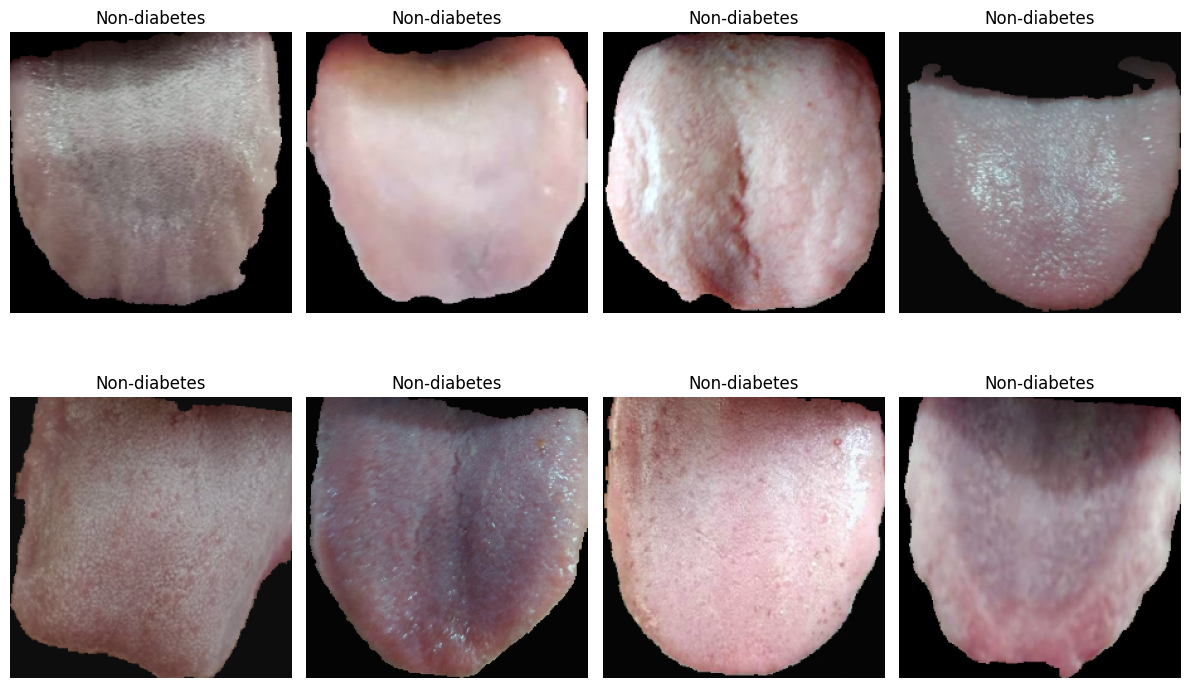

In [13]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title("Diabetes" if labels[i].item() == 1 else "Non-diabetes")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
weights = DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)

model = model.to(DEVICE)
print(model)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 169MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [15]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [16]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)

Trainable params: 1025
Total params: 6954881


In [17]:
class_counts = train_df["label"].value_counts().sort_index()
num_negative = class_counts[0]
num_positive = class_counts[1]

pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32).to(DEVICE)
print("pos_weight:", pos_weight.item())

pos_weight: 1.1940789222717285


In [18]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.detach().cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc, np.array(all_labels), np.array(all_probs)

In [21]:
EPOCHS_HEAD = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "train_precision": [],
    "train_recall": [],
    "train_f1": [],
    "train_auc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

best_val_auc = 0.0
best_model_path = "/content/drive/MyDrive/TongueImagediabetes/densenet121_best_head.pth"

In [22]:
for epoch in range(EPOCHS_HEAD):
    print(f"\nEpoch {epoch+1}/{EPOCHS_HEAD}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_precision"].append(train_precision)
    history["train_recall"].append(train_recall)
    history["train_f1"].append(train_f1)
    history["train_auc"].append(train_auc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")


Epoch 1/10


Train Loss: 0.6894 | Train AUC: 0.7000 | Train F1: 0.6199
Val   Loss: 0.5711 | Val   AUC: 0.8949 | Val   F1: 0.8209
Best model saved.

Epoch 2/10


Train Loss: 0.5546 | Train AUC: 0.8811 | Train F1: 0.7937
Val   Loss: 0.4858 | Val   AUC: 0.9209 | Val   F1: 0.8529
Best model saved.

Epoch 3/10


Train Loss: 0.4831 | Train AUC: 0.9061 | Train F1: 0.8045
Val   Loss: 0.4353 | Val   AUC: 0.9321 | Val   F1: 0.8551
Best model saved.

Epoch 4/10


Train Loss: 0.4215 | Train AUC: 0.9341 | Train F1: 0.8354
Val   Loss: 0.3971 | Val   AUC: 0.9365 | Val   F1: 0.8722
Best model saved.

Epoch 5/10


...

Train Loss: 0.4131 | Train AUC: 0.9222 | Train F1: 0.8143
Val   Loss: 0.3632 | Val   AUC: 0.9418 | Val   F1: 0.8906
Best model saved.

Epoch 7/10


Train Loss: 0.3728 | Train AUC: 0.9397 | Train F1: 0.8666
Val   Loss: 0.3623 | Val   AUC: 0.9444 | Val   F1: 0.8571
Best model saved.

Epoch 8/10


Train Loss: 0.3719 | Train AUC: 0.9392 | Train F1: 0.8641
Val   Loss: 0.3545 | Val   AUC: 0.9483 | Val   F1: 0.8571
Best model saved.

Epoch 9/10


Train Loss: 0.3744 | Train AUC: 0.9358 | Train F1: 0.8475
Val   Loss: 0.3294 | Val   AUC: 0.9519 | Val   F1: 0.9120
Best model saved.

Epoch 10/10


Train Loss: 0.3696 | Train AUC: 0.9370 | Train F1: 0.8452
Val   Loss: 0.3331 | Val   AUC: 0.9535 | Val   F1: 0.8667
Best model saved.


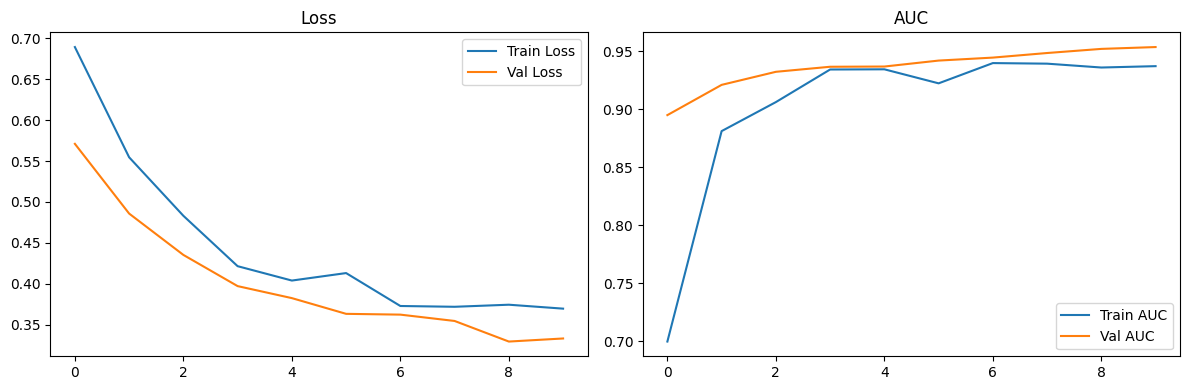

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")

plt.tight_layout()
plt.show()

In [24]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

In [25]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [26]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params after unfreezing last block:", trainable_params)

Trainable params after unfreezing last block: 2161153


In [27]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS_FINE = 10
best_finetuned_model_path = "/content/drive/MyDrive/TongueImagediabetes/densenet121_best_finetuned.pth"
best_val_auc = 0.0

In [28]:
for epoch in range(EPOCHS_FINE):
    print(f"\nFine-tuning Epoch {epoch+1}/{EPOCHS_FINE}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_finetuned_model_path)
        print("Best fine-tuned model saved.")


Fine-tuning Epoch 1/10


Train Loss: 0.2943 | Train AUC: 0.9593 | Train F1: 0.8774
Val   Loss: 0.2476 | Val   AUC: 0.9702 | Val   F1: 0.8992
Best fine-tuned model saved.

Fine-tuning Epoch 2/10


Train Loss: 0.1842 | Train AUC: 0.9877 | Train F1: 0.9402
Val   Loss: 0.1541 | Val   AUC: 0.9905 | Val   F1: 0.9147
Best fine-tuned model saved.

Fine-tuning Epoch 3/10


Train Loss: 0.1135 | Train AUC: 0.9966 | Train F1: 0.9655
Val   Loss: 0.1207 | Val   AUC: 0.9939 | Val   F1: 0.9618
Best fine-tuned model saved.

Fine-tuning Epoch 4/10


Train Loss: 0.0914 | Train AUC: 0.9978 | Train F1: 0.9722
Val   Loss: 0.1044 | Val   AUC: 0.9949 | Val   F1: 0.9618
Best fine-tuned model saved.

Fine-tuning Epoch 5/10


...

Train Loss: 0.0759 | Train AUC: 0.9978 | Train F1: 0.9787
Val   Loss: 0.0857 | Val   AUC: 0.9961 | Val   F1: 0.9767
Best fine-tuned model saved.

Fine-tuning Epoch 7/10


Train Loss: 0.0410 | Train AUC: 0.9995 | Train F1: 0.9918
Val   Loss: 0.1190 | Val   AUC: 0.9915 | Val   F1: 0.9545

Fine-tuning Epoch 8/10


Train Loss: 0.0445 | Train AUC: 0.9996 | Train F1: 0.9835
Val   Loss: 0.0975 | Val   AUC: 0.9961 | Val   F1: 0.9612

Fine-tuning Epoch 9/10


Train Loss: 0.0333 | Train AUC: 0.9997 | Train F1: 0.9885
Val   Loss: 0.0644 | Val   AUC: 0.9978 | Val   F1: 0.9692
Best fine-tuned model saved.

Fine-tuning Epoch 10/10


Train Loss: 0.0674 | Train AUC: 0.9980 | Train F1: 0.9754
Val   Loss: 0.0926 | Val   AUC: 0.9947 | Val   F1: 0.9697


In [29]:
model.load_state_dict(torch.load(best_finetuned_model_path, map_location=DEVICE))
model.eval()
print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [30]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def find_best_threshold(y_true, y_probs, metric="f1"):
    thresholds = np.arange(0.10, 0.91, 0.01)

    best_threshold = 0.50
    best_score = -1
    results = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError("metric must be 'f1', 'recall', or 'precision'")

        results.append((t, score))

        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score, results

In [31]:
val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, y_val_true, y_val_probs = evaluate(
    model, val_loader, criterion, DEVICE
)

best_threshold, best_val_f1_at_threshold, threshold_results = find_best_threshold(
    y_val_true,
    y_val_probs,
    metric="f1"
)

print(f"Best threshold from validation set: {best_threshold:.2f}")
print(f"Best validation F1 at this threshold: {best_val_f1_at_threshold:.4f}")

Best threshold from validation set: 0.20
Best validation F1 at this threshold: 0.9774


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_loss, _, _, _, _, _, y_true, y_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

y_pred = (y_probs >= best_threshold).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, zero_division=0)
test_recall = recall_score(y_true, y_pred, zero_division=0)
test_f1 = f1_score(y_true, y_pred, zero_division=0)
test_auc = roc_auc_score(y_true, y_probs)

print(f"Chosen Threshold: {best_threshold:.2f}")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test AUC-ROC:   {test_auc:.4f}")

Chosen Threshold: 0.20
Test Loss:      0.1756
Test Accuracy:  0.9444
Test Precision: 0.9265
Test Recall:    0.9545
Test F1-score:  0.9403
Test AUC-ROC:   0.9835


In [33]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[73,  5],
       [ 3, 63]])

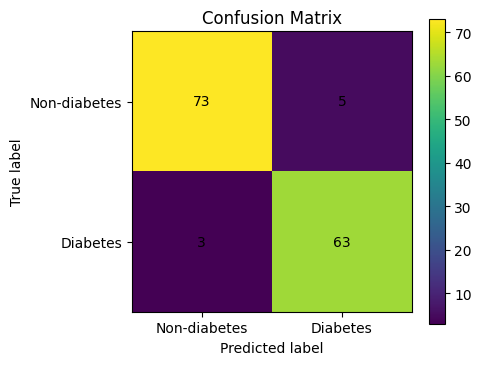

In [34]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Non-diabetes", "Diabetes"])
plt.yticks(tick_marks, ["Non-diabetes", "Diabetes"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [35]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-diabetes", "Diabetes"],
    digits=4
))

              precision    recall  f1-score   support

Non-diabetes     0.9605    0.9359    0.9481        78
    Diabetes     0.9265    0.9545    0.9403        66

    accuracy                         0.9444       144
   macro avg     0.9435    0.9452    0.9442       144
weighted avg     0.9449    0.9444    0.9445       144



In [36]:
test_results_df = test_df.copy()
test_results_df["true_label"] = y_true.astype(int)
test_results_df["pred_prob_diabetes"] = y_probs
test_results_df["pred_label"] = y_pred

save_csv_path = "/content/drive/MyDrive/TongueImagediabetes/densenet121_test_predictions.csv"
test_results_df.to_csv(save_csv_path, index=False)

print("Saved test predictions to:", save_csv_path)
test_results_df.head()

Saved test predictions to: /content/drive/MyDrive/TongueImagediabetes/densenet121_test_predictions.csv


,image_path,label,label_name,true_label,pred_prob_diabetes,pred_label
0,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.793585,1
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.999231,1
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.990001,1
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.956362,1
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.942156,1
